In [1]:
import numpy as np
from scipy.optimize import fsolve
from scipy.integrate import solve_ivp
import sys
from pathlib import Path
import importlib
# add Modeling/ to Python path
project_root = Path.cwd().parents[2]
sys.path.append(str(project_root))
import Modeling
importlib.reload(Modeling)
from Modeling.models.plotting import animate_field_1d
import Modeling.models.beam_properties as beam_properties_module
importlib.reload(beam_properties_module)
PiezoBeamParams = beam_properties_module.PiezoBeamParams
from Modeling.models import FE_helpers 
importlib.reload(FE_helpers)
import matplotlib.pyplot as plt
# from Modeling.models.ROM import ROM
import Modeling.models.FE3 as FE_module
importlib.reload(FE_module)
FE = FE_module
# import Modeling.models.ROM as ROM_module
# importlib.reload(ROM_module)
# ROM = ROM_module.ROM

# from FE1 import PiezoBeamFE, frf_sweep, solve_newmark
import numpy as np
from numpy import pi	
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from IPython.display import clear_output
from matplotlib import cm, colors
import pandas as pd
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
# K_i = 8000*0.928; K_p = 0.015; K_c =e10; R_c = 1e3
K_i = 1820; K_p = 0.015; K_c = 3e10; R_c = 1e3
# K_i = 0; K_p = 100000; K_c = 0; R_c = 1e3
# K_i = 0; K_p = 1e-5; K_c = 0; R_c = 1e3
t_end = 10
f0 = 1400
f1 = 4500

dt = 1/f1/100
# Amplitude sweep parameters
A_list = np.linspace(5, 50, 8)  # excitation amplitudes
# A_list = [50]
print(f"Running amplitude sweep for A = {A_list}...")
def v_exc(t, A_exc=50, f0=f0, f1=f1, t_end=t_end):
	return A_exc*np.sin(2*np.pi*(f0+ t*(f1-f0)/t_end) *t)
# N = 40
# hp, hs = 0.31e-3, 0.607e-3 	
# zeta_dict = { 1: 0.02, 2: 0.025, 3: 0.03, 4: 0.007, 5: 0.0075, 6:0.0085, 7:0.008, 8:0.007,
# 			 9: 0.007, 10: 0.0075, 11: 0.008, 12: 0.009, 13: 0.01, 14: 0.012, 15: 0.016, 16: 0.017,
# 			 17: 0.02, 18:0.03, 19:0.03,'rest': 0.6
# 			 } # dummy values for now

# params_fe = PiezoBeamParams(
#                             hp=0.252e-3, hs=0.51e-3,
#                             # hp=0.31e-3, hs=0.607e-3,
#                             d31= -1.45e-10,eps_r=1700,
# 							# rho_p=7700,
# 							# omega_p=2*pi*100, omega_q=2*pi*5000,
# 							# zeta_dict = zeta_dict
#                             )
params_fe = PiezoBeamParams(
	hp=0.252e-3,
	hs=0.51e-3,
	d31=-1.45e-10,
	eps_r=1700,
)
# params_fe.zeta_p = 0.0001
# params_fe.zeta_q = 0.0001
# params_fe.zeta_p = 0.15
# params_fe.zeta_q = 0.1
fe = FE_module.PiezoBeamFE(params_fe)



Running amplitude sweep for A = [ 5.         11.42857143 17.85714286 24.28571429 30.71428571 37.14285714
 43.57142857 50.        ]...


In [2]:
SAVE_PREFIX = "Chaos_hardening"
# kc0 = 6e10
# gamma = 0.5
# ki= 1800
# ki0 = (1-gamma)*ki; ki1 = (1+gamma)*ki
# K_i = 1800; K_p = 0.03; K_c = -1.6e10 ; R_c = 1e3
# K_c = np.array([kc0, -kc0]*15)
# K_i = np.array([ki0, ki1]*15+[ki0])
# t_end = 1
# f0 = 1000
# f1 = 4500
# dt = 1/f1/100
from joblib import Parallel, delayed
# Create excitation function factory
def make_v_exc(A):
	def v_exc(t_var, A_exc=A, f0=f0, f1=f1, t_end=t_end):
		return A_exc * np.sin(2*np.pi*(f0 + t_var*(f1-f0)/t_end) * t_var)
	return v_exc

# Function to run single amplitude simulation
def run_amplitude_case(A, fe, params, K_c, K_i, K_p, dt, t_end):
    """Run one simulation for given excitation amplitude A with error handling."""
    try:
        print(f"  Amplitude = {A}")
        v_exc = make_v_exc(A)
        ode = fe.build_ode_system(
            j_exc=30,
            K_c=K_c,
            K_i=K_i,
            K_p=K_p,
            R_c=R_c,
            v_exc=v_exc
        )
        result = FE_helpers.solve_newmark(
            ode=ode,
            dt=dt,
            t_end=t_end,
            beta=0.25,
            gamma=0.5,
            newton_tol=1e-8,
            newton_maxiter=10,
            x0=np.zeros(ode.M.shape[0]),
            x_dot0=np.zeros(ode.M.shape[0]),
            do_spectral=True
        )
        return {
            "status": "ok",
            "A": A,
            "freq": result['spectral']['freq'],
            "FRF": result['spectral']['FRF'],
            "Spectral": result['spectral'],
            "velocity": result['u_dot'],
            "displacement": result['u'],
            "voltage": result['v'],
            "q": result['q'],
            't': result['t']
        }
    except Exception as e:
        return {
            "status": "failed",
            "A": A,
            "error": str(e),
            "exception": type(e).__name__
        }



# Run in parallel
raw_results = Parallel(n_jobs=8, verbose=10)(
    delayed(run_amplitude_case)(A, fe, params_fe, K_c, K_i, K_p, dt, t_end)
    for A in A_list
)

# Separate successes and failures
sweep_results = [r for r in raw_results if r["status"] == "ok"]
failed = [r for r in raw_results if r["status"] == "failed"]

print("Amplitude sweep completed!")
print(f"  Successful: {len(sweep_results)} / {len(raw_results)}")
if failed:
    print("  Failed cases:")
    for f in failed:
        print(f"    A={f['A']}: {f['exception']} -> {f['error']}")

# ======= Save results (unique filename by datetime) =======
import json
import pickle
# from datetime import datetime


# TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")

def unique_path(path: Path) -> Path:
    if not path.exists():
        return path
    counter = 1
    while True:
        candidate = path.with_name(f"{path.stem}_{counter}{path.suffix}")
        if not candidate.exists():
            return candidate
        counter += 1

# Output dir
sim_dat_dir = Path.cwd() / 'sim_dat'
sim_dat_dir.mkdir(parents=True, exist_ok=True)

# Build filename (datetime only)
pkl_base = f"{SAVE_PREFIX}.pkl"
pkl_path = unique_path(sim_dat_dir / pkl_base)


[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.


TerminatedWorkerError: A worker process managed by the executor was unexpectedly terminated. This could be caused by a segmentation fault while calling the function or by an excessive memory usage causing the Operating System to kill the worker.

Detailed tracebacks of the workers should have been printed to stderr in the executor process if faulthandler was not disabled.

In [ ]:

# Pack everything
save_dict = {
    # sweep outputs
    "amp_list": A_list,
    "sweep_results": sweep_results,
    "failed": failed,
    # spectral convenience arrays (first successful case)
    "sample_freq": (sweep_results[0]['freq'] if sweep_results else None),
    # parameters
    "K_p": K_p,
    "K_i": np.asarray(K_i, dtype=float),
    # "K_i_nominal": float(ki) if 'ki' in globals() else float(np.mean(np.asarray(K_i, dtype=float))),
    # "gamma": float(gamma) if 'gamma' in globals() else 0.0,
    "K_c": np.asarray(K_c, dtype=float),
    # "K_c_abs0": float(np.abs(np.asarray(K_c, dtype=float)[0])),
    "R_c": R_c,
    "t_end": t_end,
    "f0": f0,
    "f1": f1,
    "dt": dt,
    # FE model parameters
    "params_fe_hp": params_fe.hp,
    "params_fe_hs": params_fe.hs,
    "params_fe_d31": params_fe.d31,
    "params_fe_eps_r": params_fe.eps_r,
    # "params_fe_zeta_p": params_fe.zeta_p,
    # "params_fe_zeta_q": params_fe.zeta_q
}

with open(pkl_path, "wb") as f:
    pickle.dump(save_dict, f, protocol=pickle.HIGHEST_PROTOCOL)

# Also save human-readable config (with error log included)
# Helper to safely extract first element (works for scalars and arrays)
K_c_abs0 = float(np.abs(np.asarray(K_c, dtype=float).flat[0]))
Ki_nominal = float(ki) if 'ki' in globals() else float(np.mean(np.asarray(K_i, dtype=float).flat[0]))

config_dict = {
    "amp_list": A_list.tolist(),
    "K_p": float(K_p),
    "K_i": np.asarray(K_i, dtype=float).tolist(),
    # "K_i_nominal": float(ki) if 'ki' in globals() else float(np.mean(np.asarray(K_i, dtype=float))),
    # "gamma": float(gamma) if 'gamma' in globals() else 0.0,
    "K_c": np.asarray(K_c, dtype=float).tolist(),
    # "K_c_abs0": float(np.abs(np.asarray(K_c, dtype=float)[0])),
    "R_c": float(R_c),
    "t_end": float(t_end),
    "f0": float(f0),
    "f1": float(f1),
    "dt": float(dt),
    "params_fe": {
        "hp": float(params_fe.hp),
        "hs": float(params_fe.hs),
        "d31": float(params_fe.d31),
        "eps_r": float(params_fe.eps_r),
        "zeta_p": float(params_fe.zeta_p),
        "zeta_q": float(params_fe.zeta_q)
    },
    "error_log": {
        "total": len(raw_results),
        "successful": len(sweep_results),
        "failed": len(failed),
        "failed_cases": failed,
        "tags": {
            "Ki_nominal": Ki_nominal,
            # "gamma": float(gamma) if 'gamma' in globals() else 0.0,
            "Kc_abs0": K_c_abs0
        }
    }
}

config_path = unique_path(pkl_path.with_suffix(".json"))
with open(config_path, "w") as f:
    json.dump(config_dict, f, indent=2)

print(f"Results saved to: {pkl_path}")
print(f"Config saved to: {config_path}")


Results saved to: c:\Users\setemadi3\GaTech Dropbox\Seyednima Etemadi\Projects\Metamaterial beam\Modeling\tasks\Chaotic_band\sim_dat\Chaos_hardening.pkl
Config saved to: c:\Users\setemadi3\GaTech Dropbox\Seyednima Etemadi\Projects\Metamaterial beam\Modeling\tasks\Chaotic_band\sim_dat\Chaos_hardening.json


In [ ]:
# print(data.keys())
print(sweep_results[0].keys())

dict_keys(['status', 'A', 'freq', 'FRF', 'Spectral', 'velocity', 'displacement', 'voltage', 'q', 't'])


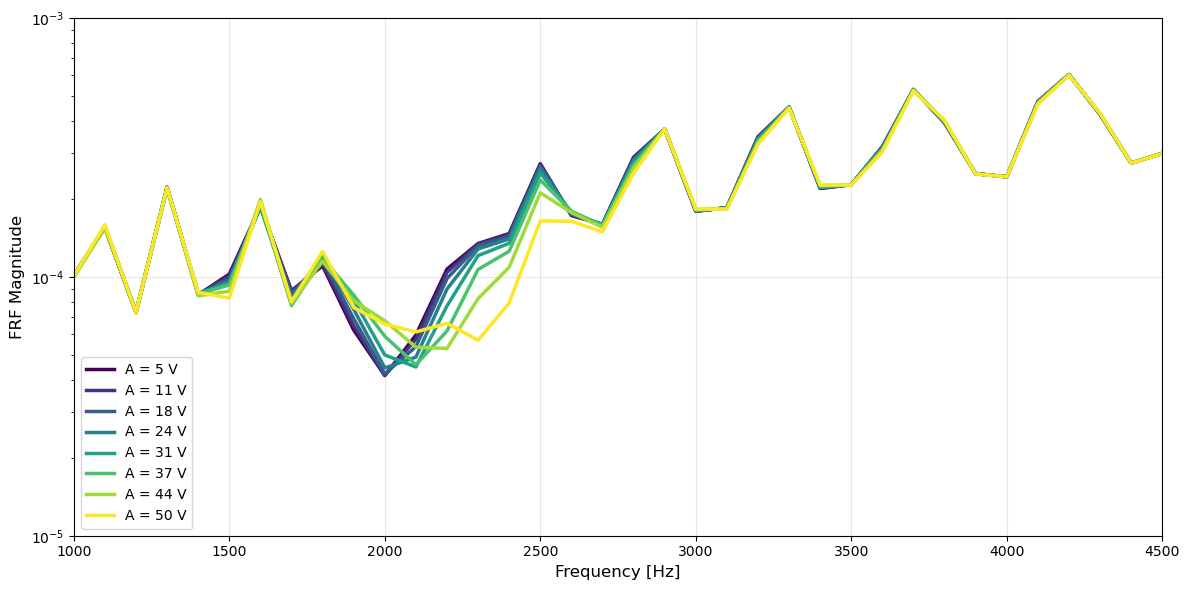

In [ ]:

# Plot FRF overlay with color gradient
plt.figure(figsize=(12, 6))
cmap = plt.cm.viridis
colors_amp = cmap(np.linspace(0, 1, len(A_list)))

for i, result in enumerate(sweep_results):
	A = result['A']
	freq = result['freq']
	frf = result['FRF']
	plt.semilogy(freq, frf, '-', linewidth=2.5, 
				label=f'A = {A:0.0f} V', color=colors_amp[i])

plt.xlabel('Frequency [Hz]', fontsize=12)
plt.ylabel('FRF Magnitude', fontsize=12)
plt.xlim([1000, 4500])
plt.ylim([1e-5, 1e-3])
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10, loc='best')
# plt.title(f'FRF vs Excitation Amplitude (Kc={K_c:.1e}, Ki={K_i:.0f}, Kp={K_p:.4f})', 
# 		fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
fe.x_nodes.shape
sweep_results[0]['velocity'].shape

In [ ]:
sweep_results[0].keys()
# sweep_results[0]['freq']
fe.geom

In [ ]:
amp_idx = 0  # Example: get results for 4th amplitude
mode_shapes = sweep_results[amp_idx]['Spectral']['Y']
# Convert complex displacement to magnitude
mode_mag = np.abs(mode_shapes)  # (Nfreq, Ndof)

# Node positions
try:
    x_nodes = fe.node_coords.squeeze()
except AttributeError:
    x_nodes = np.arange(mode_mag.shape[1])
freq_axis = sweep_results[amp_idx]['freq']

from matplotlib.colors import LogNorm

# Frequency mask: confine to region of interest
freq_min = 1000  # Hz
freq_max = 4000  # Hz
freq_mask = (freq_axis >= freq_min) & (freq_axis <= freq_max)
freq_idx = np.where(freq_mask)[0]

if len(freq_idx) == 0:
    print(f"No frequencies found in range [{freq_min}, {freq_max}]. Available range: [{freq_axis.min():.0f}, {freq_axis.max():.0f}]")
else:
    # Extract masked data
    mode_mag_masked = mode_mag[freq_mask, :]
    freq_axis_masked = freq_axis[freq_mask]
    
    # Log-scale color axis with safe vmin/vmax
    vmin = max(np.min(mode_mag_masked[mode_mag_masked > 0]), 1e-12) if np.any(mode_mag_masked > 0) else 1e-12
    vmax = mode_mag_masked.max() if mode_mag_masked.size else 1
    
    plt.figure(figsize=(10, 6))
    im = plt.imshow(
        mode_mag_masked,
        aspect='auto',
        origin='lower',
        extent=[x_nodes.min(), x_nodes.max(), freq_axis_masked.min(), freq_axis_masked.max()],
        cmap='inferno',
        # norm=LogNorm(vmin=vmin, vmax=vmax)
    )
    plt.colorbar(im, label='|displacement| [m] (log scale)')
    plt.xlabel('Position along beam')
    plt.ylabel('Frequency [Hz]')
    plt.title(f'Mode shapes heatmap ({freq_min}-{freq_max} Hz)')
    plt.tight_layout()
    plt.show()

In [ ]:


plt.figure()
plt.plot(t, w[:, 120])
plt.xlabel("Time [s]")
plt.ylabel("Displacement [m]")
plt.title("Tip displacement")
plt.grid(True)
plt.show()


plt.figure()
plt.plot( w[1, :])
plt.xlabel("Position [m]")
plt.ylabel("Displacement [m]")
plt.title("")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(t, q[:, 0])
plt.xlabel("Time [s]")
plt.ylabel("Charge [C]")
plt.title("Electrical response")
plt.grid(True)
plt.show()


In [ ]:
import importlib
from Modeling.models import plotting
importlib.reload(plotting)
amp_idx = -1
plotting.animate_field_1d_pyvista(
	t=sweep_results[amp_idx]['t'][-100:],
	u=sweep_results[amp_idx]['velocity'][-100:, :],
	x=fe.x_nodes[1:],
	filename="./anim/beam_pyvista2.mp4",
	scale=1,
    stride=1,
	ylabel="Displacement [m]",
)


In [ ]:
plotting.animate_field_1d(
	t=sweep_results[amp_idx]['t'][-100:],
	u=sweep_results[amp_idx]['velocity'][-100:, :],
	x=fe.x_nodes[1:],
	filename="./anim/beam_matplotlib2.mp4",
	scale=1,
    stride=1,
	ylabel="Displacement [m]",
)


In [ ]:
# Identify spatial point of maximum amplitude for each experimental dataset

def find_spatial_peak(frf, freq_axis, name):
    """Find spatial index of maximum amplitude across all frequencies."""
    global_max_flat_idx = np.argmax(frf)
    global_max_idx = np.unravel_index(global_max_flat_idx, frf.shape)
    
    # Handle both 2D (freq, spatial) and 3D (file, freq, spatial) cases
    is_3d = len(global_max_idx) == 3
    if is_3d:
        file_idx, freq_idx, spatial_idx = global_max_idx
        max_value = frf[file_idx, freq_idx, spatial_idx]
    else:
        freq_idx, spatial_idx = global_max_idx
        max_value = frf[freq_idx, spatial_idx]
    
    freq_at_max = freq_axis[freq_idx]
    
    return {
        "name": name,
        "spatial_idx": spatial_idx,
        "freq_idx": freq_idx,
        "freq_at_max": freq_at_max,
        "max_value": max_value,
        "is_3d": is_3d,
        "file_idx": global_max_idx[0] if is_3d else None
    }

# Datasets
datasets = {
    "OC": {"frf": frf_OC_exp, "freq": frq_OC_exp},
    "SC": {"frf": frf_SC_exp, "freq": frq_SC_exp},
    "Linear": {"frf": frf_linear_exp, "freq": frq_linear_exp}
}

# Find and display peaks
print("Maximum amplitude locations across all frequencies:\n")
peaks = []

for name, data in datasets.items():
    peak = find_spatial_peak(data["frf"], data["freq"], name)
    peaks.append(peak)
    
    print(f"{name}:")
    print(f"  Spatial index:     {peak['spatial_idx']}")
    print(f"  Frequency at max:  {peak['freq_at_max']:.2f} Hz")
    print(f"  FRF value:         {peak['max_value']:.4e}")
    if peak['is_3d']:
        print(f"  From file:         #{peak['file_idx']}")
    print()